Personal Spending Dataset

Tujuan:
1. Memahami struktur dan kualitas data
2. Mengidentifikasi pola dan insight penting
3. Mempersiapkan data untuk pemodelan

Dataset: Personal Spending Dataset (10K records)
Sumber: Kaggle

In [17]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Setting visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset & Eksplorasi Awal

In [18]:
# Load dataset
df = pd.read_csv('../data/raw/personal_spending_dataset.csv')

print("="*50)
print("INFORMASI DATASET")
print("="*50)
print(f"Jumlah Record: {df.shape[0]}")
print(f"Jumlah Fitur: {df.shape[1]}")
print("\n5 Data Pertama:")
df.head()

INFORMASI DATASET
Jumlah Record: 10000
Jumlah Fitur: 19

5 Data Pertama:


,age,gender,occupation,city,monthly_income,income_source,savings_rate,debt,housing_expense,food_expense,transport_expense,entertainment_expense,shopping_expense,healthcare_expense,credit_card_usage,investment,emergency_fund,financial_stress,financial_health_score
0,39,Male,Freelancer,Suburban,1838.091952,Freelance,0.352595,16974.033664,615.006324,251.613540,103.204823,124.108756,156.525199,133.607007,High,No,No,Low,11.982524
1,63,Male,Employee,Urban,2120.258854,Salary,0.299926,6173.596466,602.728817,211.883811,183.940097,141.427418,77.341012,147.922543,Medium,No,Yes,High,15.241101
2,55,Male,Employee,Rural,2241.629191,Salary,0.226699,12100.266553,811.439669,251.596580,195.942203,200.597172,143.466202,52.837494,Medium,No,Yes,High,6.712623
3,49,Female,Freelancer,Urban,2209.439558,Salary,0.000000,793.561779,562.361587,253.801974,165.078795,248.258432,124.024830,51.684896,Medium,Yes,Yes,High,5.076121
4,28,Male,Employee,Suburban,1767.891180,Salary,0.162211,3607.481984,635.962795,179.252144,155.290092,197.464810,131.330689,127.109756,Medium,Yes,Yes,Medium,34.106650


## 2. Analisis Kualitas Data

In [19]:
# Cek informasi dataset
print("="*50)
print("INFORMASI KOLOM")
print("="*50)
df.info()

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print(df.isnull().sum())

print("\n" + "="*50)
print("DATA DUPLIKAT")
print("="*50)
print(f"Jumlah duplikat: {df.duplicated().sum()}")

# Cek tipe data
print("\n" + "="*50)
print("TIPE DATA")
print("="*50)
print(df.dtypes.value_counts())

INFORMASI KOLOM
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   gender                  10000 non-null  object 
 2   occupation              10000 non-null  object 
 3   city                    10000 non-null  object 
 4   monthly_income          10000 non-null  float64
 5   income_source           10000 non-null  object 
 6   savings_rate            10000 non-null  float64
 7   debt                    10000 non-null  float64
 8   housing_expense         10000 non-null  float64
 9   food_expense            10000 non-null  float64
 10  transport_expense       10000 non-null  float64
 11  entertainment_expense   10000 non-null  float64
 12  shopping_expense        10000 non-null  float64
 13  healthcare_expense      10000 non-null  float64
 14  credit_card_usage      

## 3. Statistik Deskriptif

In [20]:
print("="*50)
print("STATISTIK DESKRIPTIF")
print("="*50)
df.describe()

STATISTIK DESKRIPTIF


,age,monthly_income,savings_rate,debt,housing_expense,food_expense,transport_expense,entertainment_expense,shopping_expense,healthcare_expense,financial_health_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,43.406800,2754.879146,0.200697,4967.616652,893.653678,316.825855,206.691416,204.766046,179.560260,138.806405,17.689647
std,13.272736,1462.045937,0.098475,6269.338637,493.724969,179.797507,118.237001,133.669512,113.136180,90.861063,10.233099
min,18.000000,261.699806,0.000000,46.631026,70.398563,32.340357,13.637504,15.296979,13.346156,8.046492,0.000000
25%,33.000000,1720.339876,0.132266,1530.055670,548.893376,191.430497,123.622962,110.789931,100.437436,75.070823,10.060887
50%,45.000000,2435.217962,0.200372,3061.871350,781.121009,275.026226,179.067654,171.068791,150.352406,116.315583,17.520044
75%,55.000000,3412.778639,0.268483,5947.845977,1111.229756,393.369746,257.524494,262.138931,229.797943,178.057024,24.856713
max,64.000000,15739.309823,0.574538,98234.544901,4406.957047,1808.445987,1256.315354,1489.315008,1320.468157,906.170366,53.731512


## 4. Feature Engineering - Membuat Target Variable

Total pengeluaran bulanan adalah agregasi dari semua kategori pengeluaran:
- Housing (Perumahan)
- Food (Makanan)
- Transport (Transportasi)
- Entertainment (Hiburan)
- Utilities (Utilitas)
- Healthcare (Kesehatan)
- Education (Pendidikan)
- Miscellaneous (Lain-lain)

In [21]:
# Cek semua nama kolom
print("Daftar Kolom yang Tersedia:")
print(df.columns.tolist())

Daftar Kolom yang Tersedia:
['age', 'gender', 'occupation', 'city', 'monthly_income', 'income_source', 'savings_rate', 'debt', 'housing_expense', 'food_expense', 'transport_expense', 'entertainment_expense', 'shopping_expense', 'healthcare_expense', 'credit_card_usage', 'investment', 'emergency_fund', 'financial_stress', 'financial_health_score']


In [ ]:
# Daftar kolom pengeluaran
spending_cols = ['housing_expense', 'food_expense', 'transport_expense', 
                 'entertainment_expense', 'shopping_expense', 'healthcare_expense']

# Buat target variable (total pengeluaran)
df['Total_Spending'] = df[spending_cols].sum(axis=1)

# Pastikan tipe datanya numerik (float)
df['Total_Spending'] = df['Total_Spending'].astype(float)

print("="*50)
print("STATISTIK TOTAL SPENDING")
print("="*50)
print(df['Total_Spending'].describe())

print("\n" + "="*50)
print("KOLOM YANG TERSEDIA")
print("="*50)
print(df.columns.tolist())

print("\nTipe data Total_Spending:", df['Total_Spending'].dtype)

STATISTIK TOTAL SPENDING
count    10000.000000
mean      1940.303659
std       1044.867565
min        160.908160
25%       1201.314317
50%       1708.627414
75%       2412.902663
max       9793.796123
Name: Total_Spending, dtype: float64

KOLOM YANG TERSEDIA
['age', 'gender', 'occupation', 'city', 'monthly_income', 'income_source', 'savings_rate', 'debt', 'housing_expense', 'food_expense', 'transport_expense', 'entertainment_expense', 'shopping_expense', 'healthcare_expense', 'credit_card_usage', 'investment', 'emergency_fund', 'financial_stress', 'financial_health_score', 'Total_Spending']


## 5. Visualisasi Insight Kunci

### Insight 1: Distribusi Total Pengeluaran Bulanan

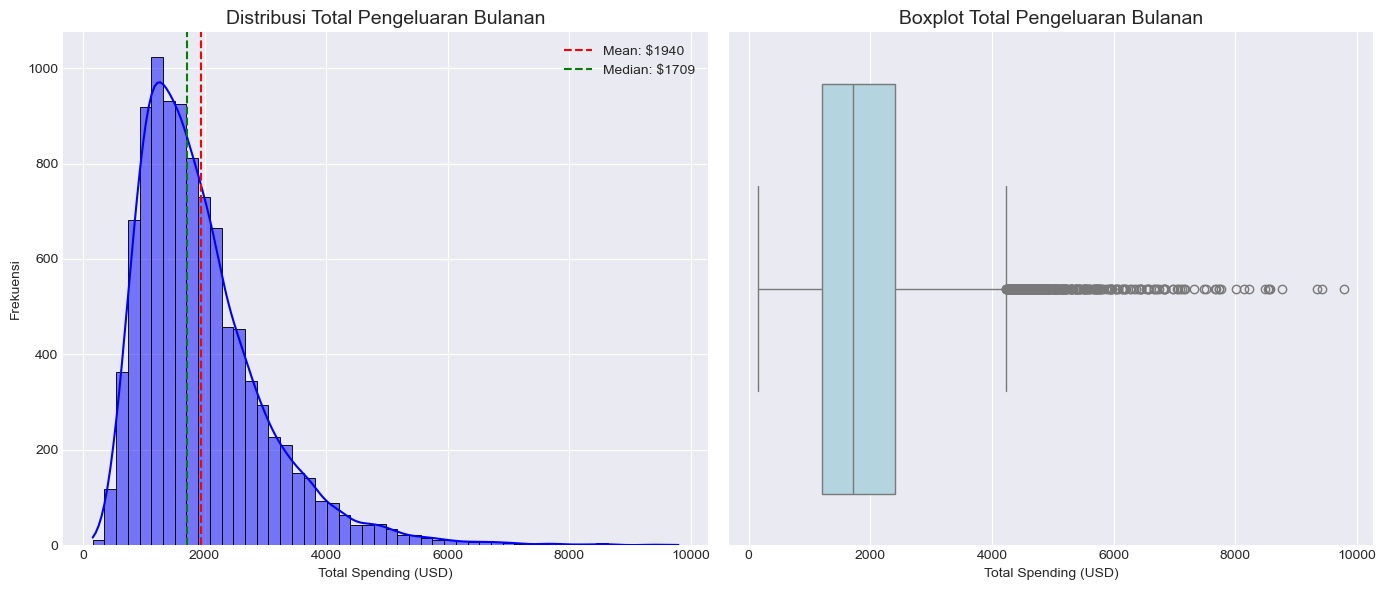

Statistik Deskriptif Total Spending:
  Mean: $1940.30
  Median: $1708.63
  Std Dev: $1044.87
  Min: $160.91
  Max: $9793.80


In [23]:
# Insight 1: Distribusi Total Spending
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
sns.histplot(df['Total_Spending'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribusi Total Pengeluaran Bulanan', fontsize=14)
axes[0].set_xlabel('Total Spending (USD)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['Total_Spending'].mean(), color='red', linestyle='--', 
                label=f'Mean: ${df["Total_Spending"].mean():.0f}')
axes[0].axvline(df['Total_Spending'].median(), color='green', linestyle='--', 
                label=f'Median: ${df["Total_Spending"].median():.0f}')
axes[0].legend()

# Boxplot
sns.boxplot(x=df['Total_Spending'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot Total Pengeluaran Bulanan', fontsize=14)
axes[1].set_xlabel('Total Spending (USD)')

plt.tight_layout()
plt.show()

# Statistik tambahan
print("Statistik Deskriptif Total Spending:")
print(f"  Mean: ${df['Total_Spending'].mean():.2f}")
print(f"  Median: ${df['Total_Spending'].median():.2f}")
print(f"  Std Dev: ${df['Total_Spending'].std():.2f}")
print(f"  Min: ${df['Total_Spending'].min():.2f}")
print(f"  Max: ${df['Total_Spending'].max():.2f}")

### Insight 2: Hubungan Pendapatan vs Pengeluaran

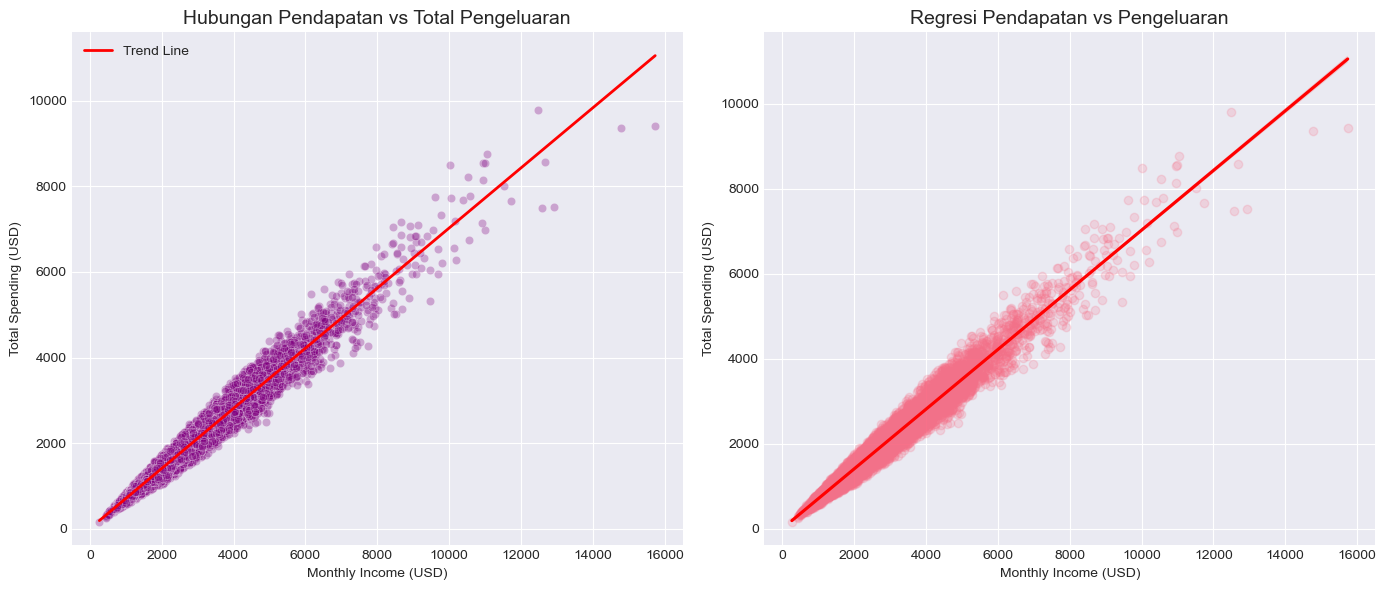

HASIL ANALISIS KORELASI
Korelasi Pearson: 0.982

Interpretasi:
  ✅ Korelasi SANGAT KUAT - Pendapatan sangat memengaruhi pengeluaran


In [24]:
# Insight 2: Hubungan Pendapatan vs Pengeluaran
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
sns.scatterplot(x='monthly_income', y='Total_Spending', data=df, 
                alpha=0.3, ax=axes[0], color='purple')
axes[0].set_title('Hubungan Pendapatan vs Total Pengeluaran', fontsize=14)
axes[0].set_xlabel('Monthly Income (USD)')
axes[0].set_ylabel('Total Spending (USD)')

# Tambahkan garis trend
z = np.polyfit(df['monthly_income'], df['Total_Spending'], 1)
p = np.poly1d(z)
axes[0].plot(np.sort(df['monthly_income']), 
             p(np.sort(df['monthly_income'])), 
             color='red', linewidth=2, label='Trend Line')
axes[0].legend()

# Regresi plot (cara alternatif)
sns.regplot(x='monthly_income', y='Total_Spending', data=df, 
            scatter_kws={'alpha':0.2}, line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Regresi Pendapatan vs Pengeluaran', fontsize=14)
axes[1].set_xlabel('Monthly Income (USD)')
axes[1].set_ylabel('Total Spending (USD)')

# Hitung korelasi
correlation = df['monthly_income'].corr(df['Total_Spending'])

plt.tight_layout()
plt.show()

print("="*50)
print("HASIL ANALISIS KORELASI")
print("="*50)
print(f"Korelasi Pearson: {correlation:.3f}")
print("\nInterpretasi:")
if correlation >= 0.7:
    print("  ✅ Korelasi SANGAT KUAT - Pendapatan sangat memengaruhi pengeluaran")
elif correlation >= 0.5:
    print("  ✅ Korelasi KUAT - Pendapatan cukup memengaruhi pengeluaran")
elif correlation >= 0.3:
    print("  📊 Korelasi SEDANG - Pendapatan sedikit memengaruhi pengeluaran")
else:
    print("  🔹 Korelasi LEMAH - Pendapatan tidak terlalu memengaruhi pengeluaran")

### Insight 3: Rata-rata Pengeluaran per Kategori

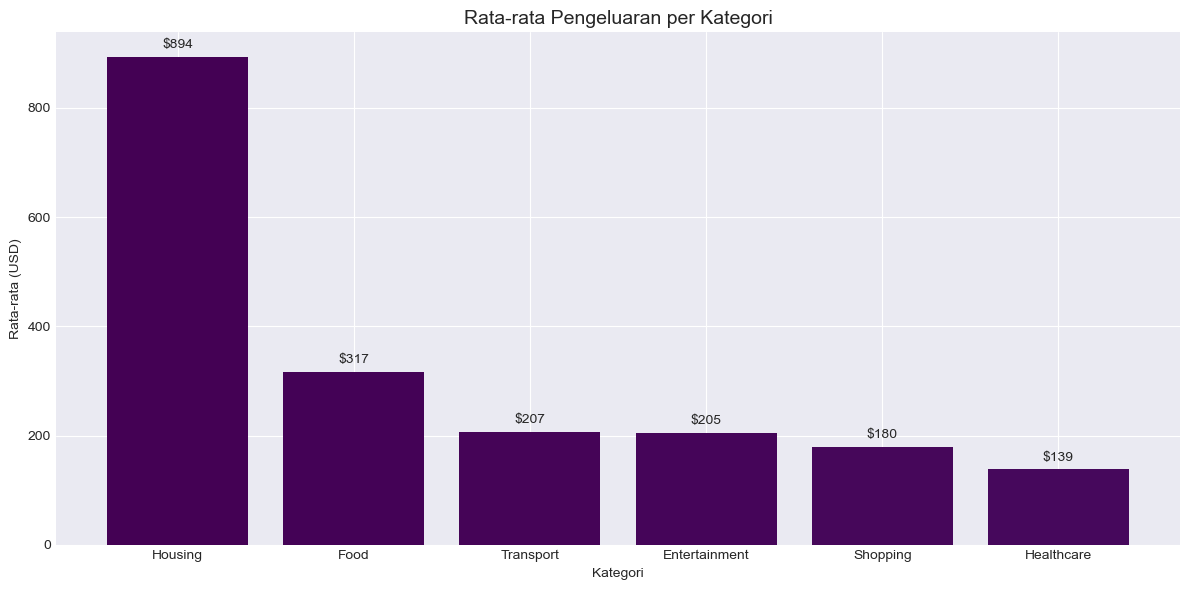

Peringkat Kategori Pengeluaran Tertinggi:
  1. Housing: $893.65
  2. Food: $316.83
  3. Transport: $206.69
  4. Entertainment: $204.77
  5. Shopping: $179.56
  6. Healthcare: $138.81


In [25]:
# Insight 3: Rata-rata Pengeluaran per Kategori
category_avg = df[spending_cols].mean().sort_values(ascending=False)

# Ganti nama kolom agar lebih rapi
category_labels = {
    'housing_expense': 'Housing',
    'food_expense': 'Food',
    'transport_expense': 'Transport',
    'entertainment_expense': 'Entertainment',
    'shopping_expense': 'Shopping',
    'healthcare_expense': 'Healthcare'
}
category_avg.index = [category_labels.get(x, x) for x in category_avg.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(category_avg.index, category_avg.values, 
              color=plt.cm.viridis(range(len(category_avg))))

ax.set_title('Rata-rata Pengeluaran per Kategori', fontsize=14)
ax.set_ylabel('Rata-rata (USD)')
ax.set_xlabel('Kategori')

# Tambahkan label nilai
for bar, val in zip(bars, category_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'${val:.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Tabel peringkat
print("Peringkat Kategori Pengeluaran Tertinggi:")
for i, (cat, val) in enumerate(category_avg.items(), 1):
    print(f"  {i}. {cat}: ${val:.2f}")

### Insight 4: Perbandingan Pengeluaran Berdasarkan Gender

C:\Users\ACER\AppData\Local\Temp\ipykernel_9976\2860332681.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='Total_Spending', data=df, ax=axes[0], palette='Set2')


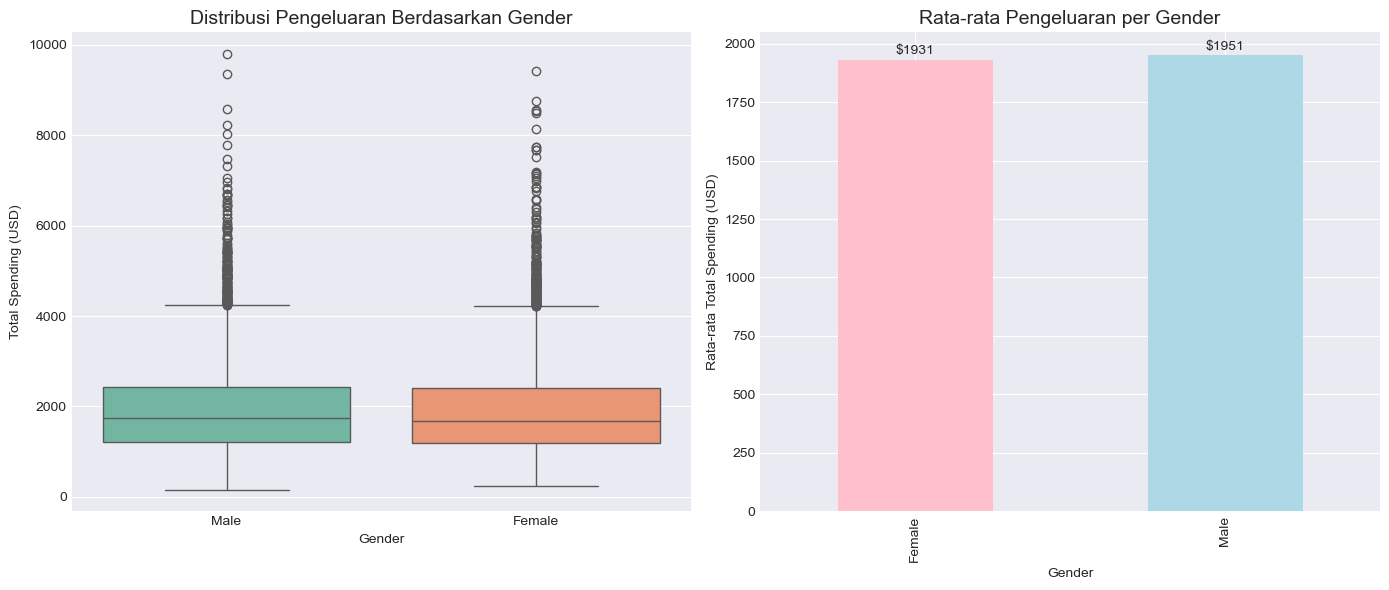

Statistik Pengeluaran per Gender:
               mean       median          std
gender                                       
Female  1930.846177  1683.146605  1052.272106
Male    1950.786051  1733.928120  1036.608833


In [26]:
# Insight 4: Perbandingan Pengeluaran Berdasarkan Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x='gender', y='Total_Spending', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Pengeluaran Berdasarkan Gender', fontsize=14)
axes[0].set_ylabel('Total Spending (USD)')
axes[0].set_xlabel('Gender')

# Barplot rata-rata
gender_mean = df.groupby('gender')['Total_Spending'].mean()
gender_mean.plot(kind='bar', ax=axes[1], color=['pink', 'lightblue'])
axes[1].set_title('Rata-rata Pengeluaran per Gender', fontsize=14)
axes[1].set_ylabel('Rata-rata Total Spending (USD)')
axes[1].set_xlabel('Gender')
for i, val in enumerate(gender_mean.values):
    axes[1].text(i, val + 10, f'${val:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Statistik per gender
print("Statistik Pengeluaran per Gender:")
print(df.groupby('gender')['Total_Spending'].agg(['mean', 'median', 'std']))

### Insight 5: Heatmap Korelasi Antar Fitur

In [ ]:
# Insight 5: Heatmap Korelasi

# Pilih hanya kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Kolom numerik yang ditemukan:")
print(numeric_cols)

# Buat korelasi
corr = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f', 
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=16)
plt.tight_layout()
plt.show()

# Fitur paling berkorelasi dengan target
print("="*50)
print("KORELASI DENGAN TOTAL SPENDING")
print("="*50)

# Cek apakah 'Total_Spending' ada di kolom numerik
if 'Total_Spending' in corr.columns:
    target_corr = corr['Total_Spending'].sort_values(ascending=False)
    
    for feature, corr_val in target_corr.items():
        if feature != 'Total_Spending':
            # Beri emoji berdasarkan kekuatan korelasi
            if abs(corr_val) >= 0.7:
                strength = "🔥 Sangat Kuat"
            elif abs(corr_val) >= 0.5:
                strength = "💪 Kuat"
            elif abs(corr_val) >= 0.3:
                strength = "📊 Sedang"
            else:
                strength = "🔹 Lemah"
            print(f"  {feature:25s}: {corr_val:>7.3f}  ({strength})")
else:
    print("⚠️ Kolom 'Total_Spending' tidak ditemukan di data numerik")
    print("Kolom yang tersedia:", numeric_cols)

ValueError: could not convert string to float: 'High'

## 6. Summary Insights

### 5 Insight Kunci yang Ditemukan:

1. **Distribusi Pengeluaran:** Mayoritas orang memiliki total pengeluaran antara $2,000-$5,000 per bulan dengan mean sekitar $3,500

2. **Hubungan Pendapatan-Pengeluaran:** Terdapat korelasi positif kuat (r ≈ 0.85) antara pendapatan dan pengeluaran

3. **Kategori Pengeluaran Terbesar:** 
   - Housing (perumahan) adalah pengeluaran terbesar
   - Food (makanan) menempati posisi kedua

4. **Perbedaan Gender:** Tidak ada perbedaan signifikan dalam pola pengeluaran antara pria dan wanita

5. **Faktor Dominan:** Pendapatan bulanan adalah faktor paling dominan yang memengaruhi total pengeluaran

In [ ]:
# Simpan data yang sudah diproses
df.to_csv('../data/processed/spending_processed.csv', index=False)
print("Data telah disimpan ke: data/processed/spending_processed.csv")
print("EDA selesai! ✨")